2015년부터 2025년까지 API로 데이터 가져오기

In [5]:
import requests
import json
import time
import os

API_KEY = "bc9bda5ee7564df4aeaf4253f0d0e7ec"

START_YEAR = 2025
END_YEAR = 2025
SAVE_DIR = "rawg_date"

os.makedirs(SAVE_DIR, exist_ok=True)

def fetch_year(year):
    print(f"\n{year}")
    all_games = []
    page = 1

    while True:
        url = (
            f"https://api.rawg.io/api/games"
            f"?key={API_KEY}"
            f"&dates={year}-01-01,{year}-12-31"
            f"&page_size=40&page={page}"
        )
        
        response = requests.get(url)
        if response.status_code != 200:
            print(f"Error {response.status_code} — stopping year {year}")
            break

        data = response.json()
        results = data.get("results", [])
        
        if not results:
            break

        for game in results:
            game["year"] = year  # 연도 칼럼 추가
            all_games.append(game)
        
        print(f"페이지 {page} ({len(results)}개)")
        page += 1
        
        time.sleep(0.5)

    # 연도별 저장
    save_path = f"{SAVE_DIR}/rawg_{year}.json"
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(all_games, f, indent=2, ensure_ascii=False)
    
    print(f"{year} data {save_path}  (총 {len(all_games)} 개)")
    return all_games


# 실행
for year in range(START_YEAR, END_YEAR + 1):
    fetch_year(year)



2025
페이지 1 (40개)
페이지 2 (40개)
페이지 3 (40개)
페이지 4 (40개)
페이지 5 (40개)
페이지 6 (40개)
페이지 7 (40개)
페이지 8 (40개)
페이지 9 (40개)
페이지 10 (40개)
페이지 11 (40개)
페이지 12 (40개)
페이지 13 (40개)
페이지 14 (40개)
페이지 15 (40개)
페이지 16 (40개)
페이지 17 (40개)
페이지 18 (40개)
페이지 19 (40개)
페이지 20 (40개)
페이지 21 (40개)
페이지 22 (40개)
페이지 23 (40개)
페이지 24 (40개)
페이지 25 (40개)
페이지 26 (40개)
페이지 27 (40개)
페이지 28 (40개)
페이지 29 (40개)
페이지 30 (40개)
페이지 31 (40개)
페이지 32 (40개)
페이지 33 (40개)
페이지 34 (40개)
페이지 35 (40개)
페이지 36 (40개)
페이지 37 (40개)
페이지 38 (40개)
페이지 39 (40개)
페이지 40 (40개)
페이지 41 (40개)
페이지 42 (40개)
페이지 43 (40개)
페이지 44 (40개)
페이지 45 (40개)
페이지 46 (40개)
페이지 47 (40개)
페이지 48 (40개)
페이지 49 (40개)
페이지 50 (40개)
페이지 51 (40개)
페이지 52 (40개)
페이지 53 (40개)
페이지 54 (40개)
페이지 55 (40개)
페이지 56 (40개)
페이지 57 (40개)
페이지 58 (40개)
페이지 59 (40개)
페이지 60 (40개)
페이지 61 (40개)
페이지 62 (40개)
페이지 63 (40개)
페이지 64 (40개)
페이지 65 (40개)
페이지 66 (40개)
페이지 67 (40개)
페이지 68 (40개)
페이지 69 (40개)
페이지 70 (40개)
페이지 71 (40개)
페이지 72 (40개)
페이지 73 (40개)
페이지 74 (40개)
페이지 75 (40개)
페이지 76 (40개)
페이지 77 (40개)
페이

년도별 데이터 JSON 평탄화 후 CSV로 저장

In [6]:
import json
import glob
import pandas as pd

files = glob.glob("rawg_date/*.json")  # 연도별 JSON 파일 경로
all_data = []

def extract_platforms(p_list):
    if not isinstance(p_list, list):
        return None
    return [p["platform"]["name"] for p in p_list]

def extract_stores(s_list):
    if not isinstance(s_list, list):
        return None
    return [s["store"]["name"] for s in s_list]

def extract_genres(g_list):
    if not isinstance(g_list, list):
        return None
    return [g["name"] for g in g_list]

def extract_tags(t_list):
    if not isinstance(t_list, list):
        return None
    return [t["name"] for t in t_list]

def extract_esrb(esrb):
    if isinstance(esrb, dict):
        return esrb.get("name")
    return None


for file in files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    for g in data:
        all_data.append({
            "id": g.get("id"),
            "slug": g.get("slug"),
            "name": g.get("name"),
            "released": g.get("released"),
            "year": int(g["released"][:4]) if g.get("released") else None,
            "playtime": g.get("playtime"),
            "rating": g.get("rating"),
            "ratings_count": g.get("ratings_count"),
            "metacritic": g.get("metacritic"),

            # 리스트/딕셔너리 평탄화
            "platforms": extract_platforms(g.get("platforms")),
            "stores": extract_stores(g.get("stores")),
            "genres": extract_genres(g.get("genres")),
            "tags": extract_tags(g.get("tags")),
            "esrb_rating": extract_esrb(g.get("esrb_rating")),
        })

df = pd.DataFrame(all_data)
df.to_csv("rawg_flatten.csv", index=False)
print("rawg_flatten.csv")


rawg_flatten.csv


In [ ]:
# 깃에 안올라가서 데이터 자르기
import json
import os

def split_json(input_path, output_dir, chunk_size=20000):
    # JSON 읽기
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    total = len(data)
    print(f"총 {total}개 항목 발견")

    # 출력 폴더가 없으면 생성
    os.makedirs(output_dir, exist_ok=True)

    file_name = os.path.basename(input_path).replace(".json", "")

    # 분할 저장
    part = 1
    for i in range(0, total, chunk_size):
        chunk = data[i:i + chunk_size]
        output_path = os.path.join(output_dir, f"{file_name}_part{part}.json")

        with open(output_path, "w", encoding="utf-8") as out:
            json.dump(chunk, out, ensure_ascii=False, indent=2)

        print(f"저장 완료 → {output_path} ({len(chunk)}개)")
        part += 1

split_json("./rawg_date/rawg_2024.json", "./rawg_date", chunk_size=20000)
split_json("./rawg_date/rawg_2025.json", "./rawg_date", chunk_size=20000)


총 10000개 항목 발견
저장 완료 → ./rawg_date/split\rawg_2024_part1.json (10000개)
총 10000개 항목 발견
저장 완료 → ./rawg_date/split\rawg_2025_part1.json (10000개)


한글

In [9]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

연도별로 어떤 장르가 증가하고 감소했는지 분석

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("rawg_flatten.csv")

# genres가 리스트 문자열 형태라면 eval() 또는 ast.literal_eval로 변환
import ast
df["genres"] = df["genres"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 장르 explode
df_ex = df.explode("genres")

# 연도별 장르별 출시 수 집계
genre_by_year = df_ex.groupby(["year", "genres"]).size().reset_index(name="count")

print(genre_by_year.head())


   year       genres  count
0  2015       Action   2831
1  2015    Adventure   2225
2  2015       Arcade    933
3  2015  Board Games    231
4  2015         Card    133


=== 장르별 증가/감소 추세 ===
genres  Action  Adventure  Arcade  Board Games  Card  Casual  Educational  \
year                                                                        
2015       0.0        0.0     0.0          0.0   0.0     0.0          0.0   
2016     534.0      448.0  -346.0        -77.0 -74.0   820.0         -2.0   
2017     217.0      353.0  -172.0        -40.0  13.0   625.0        -29.0   
2018    -329.0     -137.0   -87.0        -13.0 -20.0   -55.0         21.0   
2019    -782.0     -492.0  -171.0        -12.0  -4.0 -1367.0         49.0   
2020      90.0      221.0   -81.0        -38.0  -1.0   225.0         20.0   
2021    -104.0      225.0     3.0        -30.0 -12.0   217.0        -30.0   
2022       1.0      -81.0   -48.0          8.0   8.0    22.0         17.0   
2023     374.0      198.0    -8.0        -14.0 -31.0   316.0        -36.0   
2024     972.0     1201.0   -11.0        -10.0  -7.0  2251.0        -98.0   
2025    -149.0     -248.0     0.0         -2.0  -4.0   

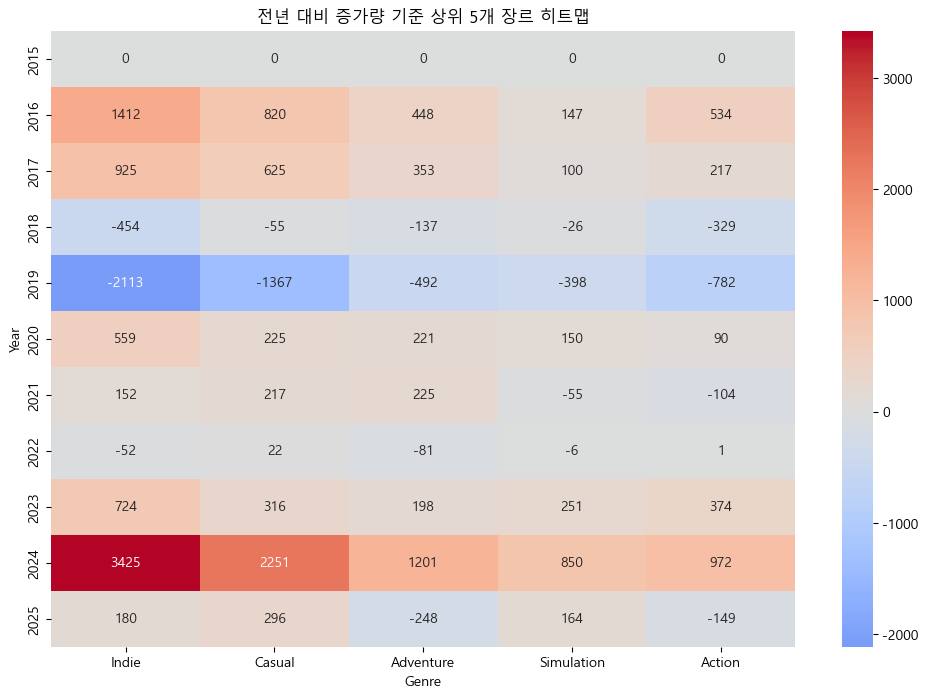

In [ ]:
# 피벗 테이블 생성
pivot = genre_by_year.pivot(index="year", columns="genres", values="count").fillna(0)

# 각 장르별 전년 대비 증가량 계산
trend = pivot.diff().fillna(0)

print("=== 장르별 증가/감소 추세 ===")
print(trend)

# 증가량 합계 기준 상위 5개 장르 선택
top5_trend_genres = trend.sum().sort_values(ascending=False).head(5).index
trend_top5 = trend[top5_trend_genres]

# 히트맵 시각화
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(trend_top5, cmap="coolwarm", center=0, annot=True, fmt=".0f")
plt.title("전년 대비 증가량 기준 상위 5개 장르 히트맵")
plt.xlabel("Genre")
plt.ylabel("Year")
plt.show()


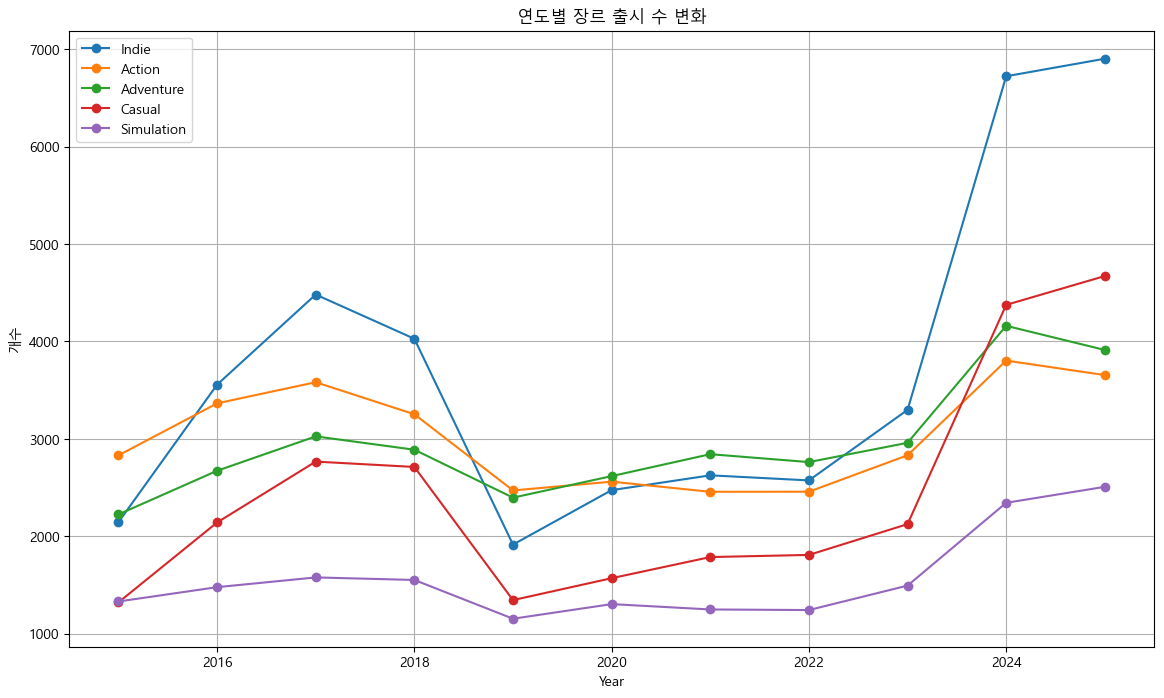

In [25]:
# 상위 5개 장르 선택
top_genres = df_ex["genres"].value_counts().head(5).index
pivot_top = pivot[top_genres]

# 시각화
plt.figure(figsize=(14, 8))
for g in top_genres:
    plt.plot(pivot_top.index, pivot_top[g], marker='o', label=g)

plt.title("연도별 장르 출시 수 변화")
plt.xlabel("Year")
plt.ylabel("개수")
plt.legend()
plt.grid(True)
plt.show()

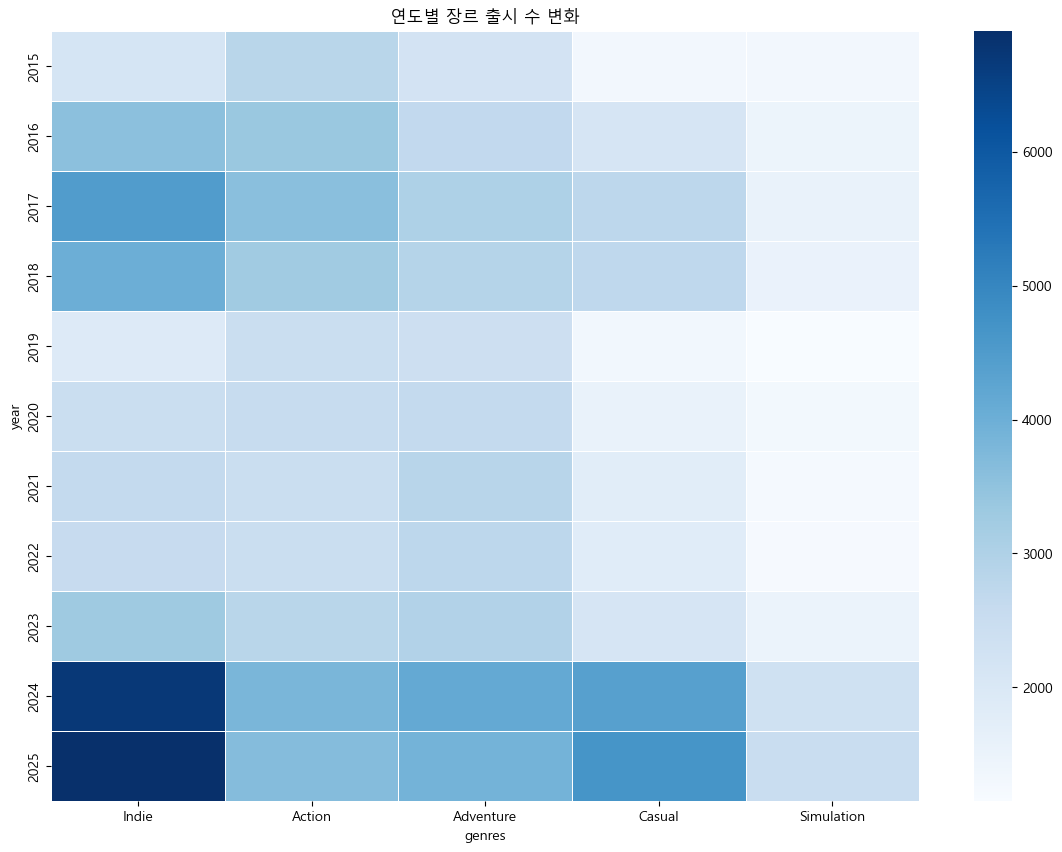

In [24]:
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_top, cmap="Blues", linewidths=0.5)
plt.title("연도별 장르 출시 수 변화")
plt.show()

연도별 플랫폼 비율

사용 플랫폼 그룹: ['Windows', 'macOS', 'Linux', 'PlayStation', 'Xbox', 'Nintendo']


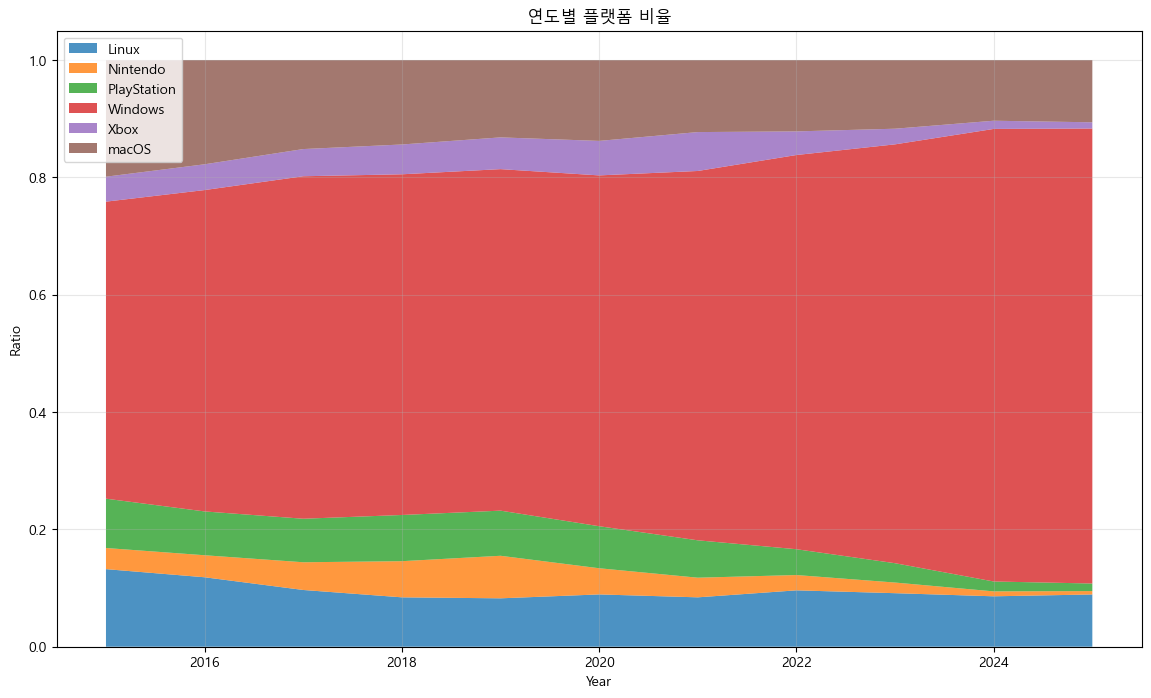

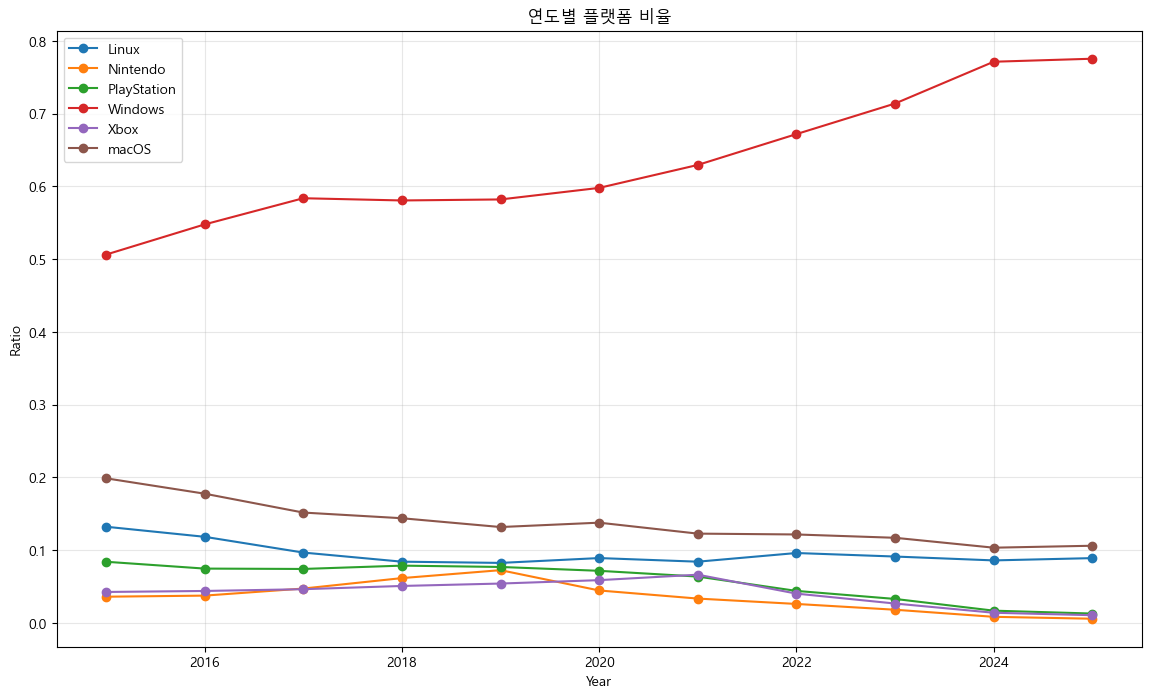

In [ ]:
df = pd.read_csv("rawg_flatten.csv")
df["platforms"] = df["platforms"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_pl = df.explode("platforms")

# 카테고리 매핑
platform_map = {
    "PC": "Windows",
    "macOS": "macOS",
    "Linux": "Linux",

    "PlayStation 3": "PlayStation",
    "PlayStation 4": "PlayStation",
    "PlayStation 5": "PlayStation",
    "PS Vita": "PlayStation",

    "Xbox 360": "Xbox",
    "Xbox One": "Xbox",
    "Xbox Series S/X": "Xbox",

    "Nintendo Switch": "Nintendo",
    "Wii U": "Nintendo",
    "Wii": "Nintendo",
}

# 매핑 적용
df_pl["platform_group"] = df_pl["platforms"].map(platform_map)

# 정의되지 않은 플랫폼 제거
df_pl = df_pl[df_pl["platform_group"].notna()]

# 플랫폼 그룹 확인
platform_counts = df_pl["platform_group"].value_counts()
platform_groups = platform_counts.index.tolist()
print("사용 플랫폼 그룹:", platform_groups)

df_pl_top = df_pl[df_pl["platform_group"].isin(platform_groups)]

# 연도 + 플랫폼 그룹별 개수
platform_by_year = (
    df_pl_top.groupby(["year", "platform_group"])
    .size()
    .reset_index(name="count")
)

# 연도별 전체 개수
total_by_year = df_pl_top.groupby("year").size()

# 비율 계산
platform_by_year["ratio"] = platform_by_year.apply(
    lambda row: row["count"] / total_by_year[row["year"]],
    axis=1
)

# 피벗 테이블
pivot_ratio = platform_by_year.pivot(
    index="year", columns="platform_group", values="ratio"
).fillna(0)

# Stacked Area Chart
plt.figure(figsize=(14, 8))

plt.stackplot(
    pivot_ratio.index,
    [pivot_ratio[col] for col in pivot_ratio.columns],
    labels=pivot_ratio.columns,
    alpha=0.8
)

plt.title("연도별 플랫폼 비율")
plt.xlabel("Year")
plt.ylabel("Ratio")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

# Line Plot
plt.figure(figsize=(14, 8))

for col in pivot_ratio.columns:
    plt.plot(pivot_ratio.index, pivot_ratio[col], marker='o', label=col)

plt.title("연도별 플랫폼 비율")
plt.xlabel("Year")
plt.ylabel("Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


게임 리뷰 평점에 따른 메타크리틱 점수 예측

C:\Users\yttr3\AppData\Local\Temp\ipykernel_20216\3767688199.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["ratings_count"] = np.log1p(X["ratings_count"])


Gradient Boosting 예측 성능
MSE : 0.1806
RMSE: 0.4249
MAE : 0.2941
R²  : 0.9032

메타크리틱 88점, 평점 수 5000개 게임 예상 유저 평점: 4.321


c:\Users\yttr3\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


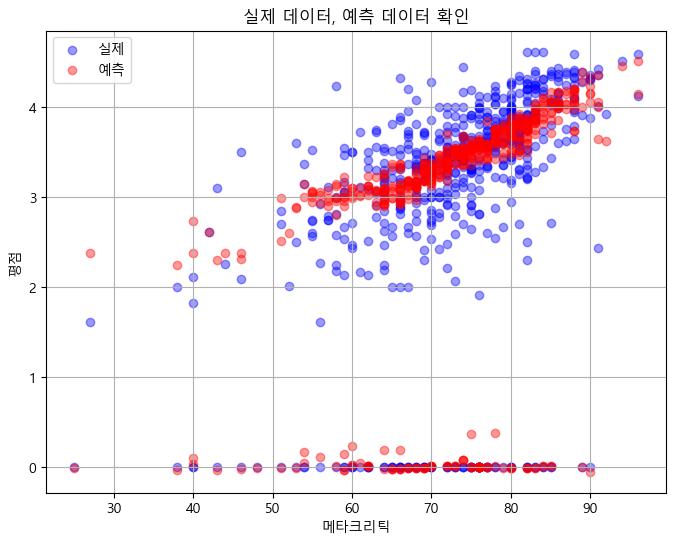

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("rawg_flatten.csv")

# 메타크리틱, 유저 평점, 평점 개수 결측치 제거
df = df.dropna(subset=["metacritic", "rating", "ratings_count"])

# 입력 X, 출력 y
X = df[["metacritic", "ratings_count"]]
y = df["rating"]

# ratings_count log 변환(스케일 차이 해결)
X["ratings_count"] = np.log1p(X["ratings_count"])

# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# GradientBoostingRegressor 비선형 모델 생성
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 정확도 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Gradient Boosting 예측 성능")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

# 테스트 예측
test_meta = 88
test_count = 5000

test_input = [[test_meta, np.log1p(test_count)]]
pred_example = model.predict(test_input)[0]

print(f"\n메타크리틱 {test_meta}점, 평점 수 {test_count}개 게임 예상 유저 평점: {pred_example:.3f}")

plt.figure(figsize=(8, 6))

plt.scatter(X_test["metacritic"], y_test, alpha=0.4, label="실제", color="blue")
plt.scatter(X_test["metacritic"], y_pred, alpha=0.4, label="예측", color="red")

plt.xlabel("메타크리틱")
plt.ylabel("평점")
plt.title("실제 데이터, 예측 데이터 확인")
plt.legend()
plt.grid(True)
plt.show()
